In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# загрузка данных из файла csv
df = pd.read_csv("vgsales.csv")

# показ первых 10 строк таблицы
df.head(10)


,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37
5,6,Tetris,GB,1989.0,Puzzle,Nintendo,23.20,2.26,4.22,0.58,30.26
6,7,New Super Mario Bros.,DS,2006.0,Platform,Nintendo,11.38,9.23,6.50,2.90,30.01
7,8,Wii Play,Wii,2006.0,Misc,Nintendo,14.03,9.20,2.93,2.85,29.02
8,9,New Super Mario Bros. Wii,Wii,2009.0,Platform,Nintendo,14.59,7.06,4.70,2.26,28.62
9,10,Duck Hunt,NES,1984.0,Shooter,Nintendo,26.93,0.63,0.28,0.47,28.31


In [8]:
# размеры таблицы строк и столбцов
print(df.shape)

# имена всех колонок
print(df.columns)

# типы данных по колонкам
print(df.dtypes)

# общая статистика минимум максимум среднее
print(df.describe())

#Ответы на вопросы:
#числовые столбцы rank year na_sales eu_sales jp_sales other_sales global_sales
#текстовые столбцы name platform genre publisher
#данные о продажах na_sales eu_sales jp_sales other_sales global_sales


(16598, 11)
Index(['Rank', 'Name', 'Platform', 'Year', 'Genre', 'Publisher', 'NA_Sales',
       'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales'],
      dtype='object')
Rank              int64
Name             object
Platform         object
Year            float64
Genre            object
Publisher        object
NA_Sales        float64
EU_Sales        float64
JP_Sales        float64
Other_Sales     float64
Global_Sales    float64
dtype: object
               Rank          Year      NA_Sales      EU_Sales      JP_Sales  \
count  16598.000000  16327.000000  16598.000000  16598.000000  16598.000000   
mean    8300.605254   2006.406443      0.264667      0.146652      0.077782   
std     4791.853933      5.828981      0.816683      0.505351      0.309291   
min        1.000000   1980.000000      0.000000      0.000000      0.000000   
25%     4151.250000   2003.000000      0.000000      0.000000      0.000000   
50%     8300.500000   2007.000000      0.080000      0.020000      0.00000

'\nОтветы на вопросы:\nчисловые столбцы rank year na_sales eu_sales jp_sales other_sales global_sales\nтекстовые столбцы name platform genre publisher\nданные о продажах na_sales eu_sales jp_sales other_sales global_sales\n'

In [10]:
# подсчет пустых мест в каждом столбце
print(df.isnull().sum())

# показ строк где год выпуска пустой
df[df["Year"].isnull()]
#Ответы на вопросы:
#пропуски есть в столбцах year и publisher
#в year пропусков 271 в publisher пропусков 58 (в вашем файле пропуски заменены на N/A)
#больше всего пропусков в столбце year

Rank              0
Name              0
Platform          0
Year            271
Genre             0
Publisher        58
NA_Sales          0
EU_Sales          0
JP_Sales          0
Other_Sales       0
Global_Sales      0
dtype: int64


,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
179,180,Madden NFL 2004,PS2,NaN,Sports,Electronic Arts,4.26,0.26,0.01,0.71,5.23
377,378,FIFA Soccer 2004,PS2,NaN,Sports,Electronic Arts,0.59,2.36,0.04,0.51,3.49
431,432,LEGO Batman: The Videogame,Wii,NaN,Action,Warner Bros. Interactive Entertainment,1.86,1.02,0.00,0.29,3.17
470,471,wwe Smackdown vs. Raw 2006,PS2,NaN,Fighting,NaN,1.57,1.02,0.00,0.41,3.00
607,608,Space Invaders,2600,NaN,Shooter,Atari,2.36,0.14,0.00,0.03,2.53
...,...,...,...,...,...,...,...,...,...,...,...
16307,16310,Freaky Flyers,GC,NaN,Racing,Unknown,0.01,0.00,0.00,0.00,0.01
16327,16330,Inversion,PC,NaN,Shooter,Namco Bandai Games,0.01,0.00,0.00,0.00,0.01
16366,16369,Hakuouki: Shinsengumi Kitan,PS3,NaN,Adventure,Unknown,0.01,0.00,0.00,0.00,0.01
16427,16430,Virtua Quest,GC,NaN,Role-Playing,Unknown,0.01,0.00,0.00,0.00,0.01


In [9]:
# удаление строк где нет года выпуска
df_clean = df.dropna(subset=["Year"])

# проверка нового размера таблицы
print(df_clean.shape)

# проверка пропусков после очистки
print(df_clean.isnull().sum())

#Ответы на вопросы:
#в исходном датасете было 16598 строк
#осталось после удаления 16327 строк
#пустые года мешают делать графики по времени и правильно считать динамику продаж

(16327, 11)
Rank             0
Name             0
Platform         0
Year             0
Genre            0
Publisher       36
NA_Sales         0
EU_Sales         0
JP_Sales         0
Other_Sales      0
Global_Sales     0
dtype: int64


In [25]:
# вывод уникальных жанров и их количества
print(df_clean["Genre"].unique())
print(df_clean["Genre"].nunique())

# вывод уникальных платформ и их количества
print(df_clean["Platform"].unique())
print(df_clean["Platform"].nunique())

# вывод количества уникальных издателей
print(df_clean["Publisher"].nunique())

#ответы на вопросы задания 5:
#жанров всего 12
#платформ всего 31
#издателей всего 578
#больше всего уникальных значений у признака publisher


['Sports' 'Platform' 'Racing' 'Role-Playing' 'Puzzle' 'Misc' 'Shooter'
 'Simulation' 'Action' 'Fighting' 'Adventure' 'Strategy']
12
['Wii' 'NES' 'GB' 'DS' 'X360' 'PS3' 'PS2' 'SNES' 'GBA' '3DS' 'PS4' 'N64'
 'PS' 'XB' 'PC' '2600' 'PSP' 'XOne' 'GC' 'WiiU' 'GEN' 'DC' 'PSV' 'SAT'
 'SCD' 'WS' 'NG' 'TG16' '3DO' 'GG' 'PCFX']
31
576


In [12]:
# группировка по жанру и подсчет имен игр
genre_count = df_clean.groupby("Genre")["Name"].count()

# сортировка от большего к меньшему
genre_count_sorted = genre_count.sort_values(ascending=False)
print(genre_count_sorted)


Genre
Action          3253
Sports          2304
Misc            1710
Role-Playing    1471
Shooter         1282
Adventure       1276
Racing          1226
Platform         876
Simulation       851
Fighting         836
Strategy         671
Puzzle           571
Name: Name, dtype: int64


In [13]:
# группировка по жанру и сумма мировых продаж
genre_sales = df_clean.groupby("Genre")["Global_Sales"].sum()

# сортировка от больших продаж к малым
genre_sales_sorted = genre_sales.sort_values(ascending=False)
print(genre_sales_sorted)


Genre
Action          1722.88
Sports          1309.24
Shooter         1026.20
Role-Playing     923.84
Platform         829.15
Misc             797.62
Racing           726.77
Fighting         444.05
Simulation       390.16
Puzzle           242.22
Adventure        234.80
Strategy         173.43
Name: Global_Sales, dtype: float64


In [14]:
# поиск 10 самых продаваемых игр в мире
top10_games = df_clean.nlargest(10, "Global_Sales")

# вывод только нужных колонок
print(top10_games[["Rank", "Name", "Platform", "Genre", "Global_Sales"]])


   Rank                       Name Platform         Genre  Global_Sales
0     1                 Wii Sports      Wii        Sports         82.74
1     2          Super Mario Bros.      NES      Platform         40.24
2     3             Mario Kart Wii      Wii        Racing         35.82
3     4          Wii Sports Resort      Wii        Sports         33.00
4     5   Pokemon Red/Pokemon Blue       GB  Role-Playing         31.37
5     6                     Tetris       GB        Puzzle         30.26
6     7      New Super Mario Bros.       DS      Platform         30.01
7     8                   Wii Play      Wii          Misc         29.02
8     9  New Super Mario Bros. Wii      Wii      Platform         28.62
9    10                  Duck Hunt      NES       Shooter         28.31


In [15]:
# число игр на каждой платформе топ 10
platform_count = df_clean.groupby("Platform")["Name"].count().nlargest(10)
print(platform_count)

# суммарные продажи по платформам топ 10
platform_sales = (
    df_clean.groupby("Platform")["Global_Sales"].sum().nlargest(10)
)
print(platform_sales)


Platform
DS      2133
PS2     2127
PS3     1304
Wii     1290
X360    1235
PSP     1197
PS      1189
PC       943
GBA      811
XB       803
Name: Name, dtype: int64
Platform
PS2     1233.46
X360     969.61
PS3      949.35
Wii      909.81
DS       818.96
PS       727.39
GBA      313.56
PSP      291.71
PS4      278.10
PC       255.05
Name: Global_Sales, dtype: float64


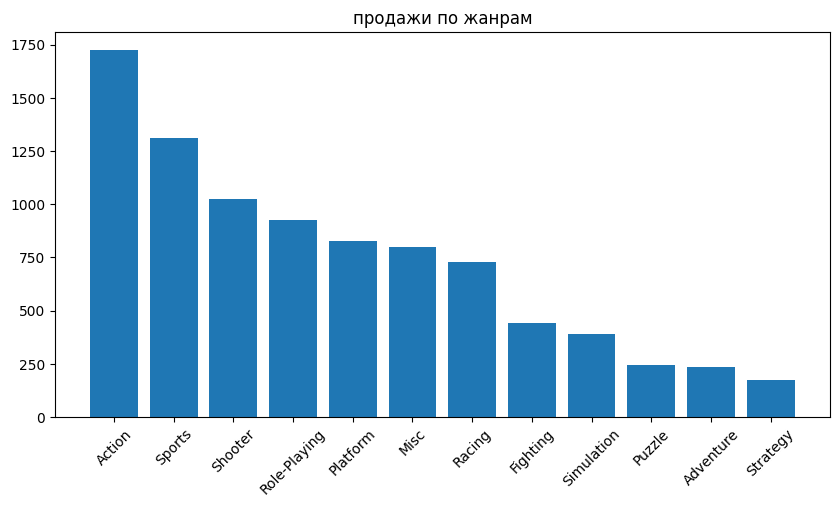

In [26]:
# сортировка продаж для графика
genre_sales_plot = genre_sales.sort_values(ascending=False)

# создание столбчатой диаграммы
plt.figure(figsize=(10, 5))
plt.bar(genre_sales_plot.index, genre_sales_plot.values)
plt.title("продажи по жанрам")
plt.xticks(rotation=45)
plt.show()

#ответы на вопросы зад 10:
#самые большие продажи у жанров action и sports
#самые маленькие продажи у жанров strategy и puzzle
#значения отличаются очень сильно экшен продается почти в 10 раз лучше стратегий


In [17]:
# расчет корреляции между америкой и миром
corr_na_global = df_clean[["NA_Sales", "Global_Sales"]].corr()
print(corr_na_global)

# ответы на вопросы задания 11
# значение получилось положительное
# значение около 0.94 это очень близко к 1
# да можно говорить о выраженной положительной взаимосвязи между na_sales и global_sales


              NA_Sales  Global_Sales
NA_Sales      1.000000      0.941268
Global_Sales  0.941268      1.000000


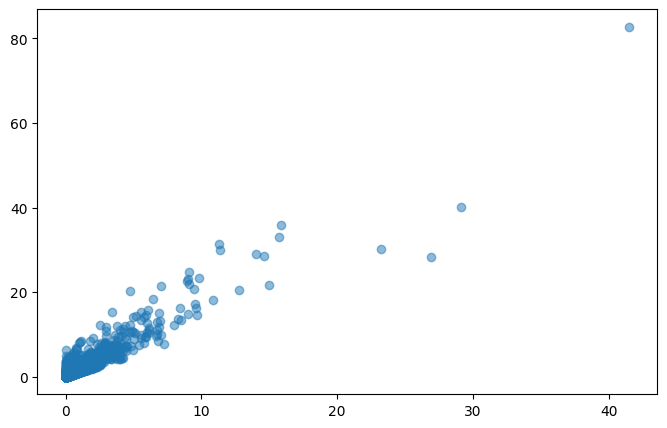

In [27]:
# график рассеяния для проверки связи
plt.figure(figsize=(8, 5))
plt.scatter(df_clean["NA_Sales"], df_clean["Global_Sales"], alpha=0.5)
# plt.title('связь продаж в северной америке и мировых продаж')
# plt.xlabel('продажи в северной америке млн')
# plt.ylabel('мировые продажи млн')
plt.show()

#ответы на вопросы:
#одна точка на графике обозначает одну конкретную игру из таблицы
#да на графике четко наблюдается восходящая тенденция точки идут вверх и вправо
#да график полностью соответствует результату корреляционного анализа и подтверждает его


In [28]:
# таблица корреляции между всеми регионами
regions_corr = df_clean[
    ["NA_Sales", "EU_Sales", "JP_Sales", "Other_Sales"]
].corr()
print(regions_corr)

#ответы на вопросы задания 13"
#сильнее всего связаны между собой региональные продажи в северной америке и европе их коэффициент около 0.70
#продажи японии хуже всего связаны со всеми остальными регионами у них самый низкий коэффициент около 0.45
#вывод американский и европейский рынки очень похожи по вкусам а японский рынок сильно отличается и покупает свои уникальные игры


             NA_Sales  EU_Sales  JP_Sales  Other_Sales
NA_Sales     1.000000  0.768936  0.451285     0.634508
EU_Sales     0.768936  1.000000  0.436414     0.726266
JP_Sales     0.451285  0.436414  1.000000     0.290653
Other_Sales  0.634508  0.726266  0.290653     1.000000
